In [5]:
# 在主函数前添加这段代码来生成测试数据
import pandas as pd

# 读取原始台风数据
df = pd.read_csv('../数据/typhoon_daily_boluo.csv')

def create_typhoon_features(df):
    """
    创建增强的台风特征 - 改进版
    
    改进点：
    1. 使用非线性变换处理距离特征（sigmoid函数）
    2. 创建更有物理意义的综合影响指数
    3. 添加相对位置特征（台风相对于博罗站的位置）
    4. 使用标准化处理气压特征
    5. 创建强度累积特征（不仅看是否有台风，还看影响强度）
    """
    df = df.copy()
    
    # 1. 台风活跃标志（最基础的二值特征）
    df['台风活跃'] = (df['台风等级'] != 0).astype(int)
    
    # 2. 台风强度等级数值化
    def map_intensity(val):
        if pd.isna(val) or val == 0 or val == '0':
            return 0
        
        val_str = str(val).upper()
        
        if 'TD' in val_str or '热带低压' in val_str:
            return 1
        elif 'TS' in val_str or ('热带风暴' in val_str and '强' not in val_str):
            return 2
        elif 'STS' in val_str or '强热带风暴' in val_str:
            return 3
        elif 'STY' in val_str or '超强台风' in val_str:
            return 6
        elif 'TY' in val_str or ('台风' in val_str and '超强' not in val_str and '强' not in val_str):
            return 4
        elif '强台风' in val_str:
            return 5
        else:
            try:
                return float(val)
            except:
                return 0
    
    df['台风强度编码'] = df['台风强度'].apply(map_intensity)
    
    # 3. 【改进】台风距离影响权重（使用sigmoid函数进行非线性变换）
    # sigmoid函数将距离转换为0-1的影响权重
    # 距离250km时影响权重为0.5，距离越近权重越大
    df['台风距离影响'] = df.apply(
        lambda row: 1 / (1 + np.exp((row['距离博罗站'] - 250) / 50)) if row['距离博罗站'] > 0 else 0,
        axis=1
    )
    
    # 4. 【改进】台风综合影响指数（考虑风速、等级和距离的非线性综合影响）
    df['台风综合影响'] = df['风速'] * df['台风等级'] * df['台风距离影响']
    
    # 5. 【改进】台风风力等级（基于蒲福风级标准）
    def classify_wind(speed):
        if speed == 0:
            return 0
        elif speed < 17.2:
            return 1  # 热带低压
        elif speed < 24.5:
            return 2  # 热带风暴
        elif speed < 32.7:
            return 3  # 强热带风暴
        elif speed < 41.5:
            return 4  # 台风
        elif speed < 51.0:
            return 5  # 强台风
        else:
            return 6  # 超强台风
    
    df['风力等级'] = df['风速'].apply(classify_wind)
    
    # 6. 【改进】气压强度（标准化处理，相对于标准大气压的偏差）
    # 气压越低，台风越强，除以50进行标准化
    df['气压强度'] = df.apply(
        lambda row: (1013.25 - row['气压']) / 50 if row['气压'] > 0 else 0,
        axis=1
    )
    
    # 7. 台风持续时间特征
    df['台风持续天数'] = df['台风起始距今天数']
    
    # 8. 台风出现累积（滑动窗口 - 统计是否有台风）
    df['台风累积3天'] = df['台风活跃'].rolling(window=3, min_periods=1).sum()
    df['台风累积7天'] = df['台风活跃'].rolling(window=7, min_periods=1).sum()
    
    # 9. 【新增】台风影响强度累积（滑动窗口 - 统计台风影响强度的平均值）
    # 这个特征不仅看是否有台风，还考虑台风的实际影响强度
    df['台风强度累积3天'] = df['台风综合影响'].rolling(window=3, min_periods=1).mean()
    df['台风强度累积7天'] = df['台风综合影响'].rolling(window=7, min_periods=1).mean()
    
    # 10. 台风移动特征
    df['台风经度变化'] = df['台风经度'].diff().fillna(0)
    df['台风纬度变化'] = df['台风纬度'].diff().fillna(0)
    df['台风移动速度'] = np.sqrt(df['台风经度变化']**2 + df['台风纬度变化']**2)
    
    # 11. 【新增】台风相对位置特征（相对于博罗站的经纬度偏差）
    # 这样可以捕捉台风的方向信息
    boluo_lon = 114.2967
    boluo_lat = 23.15881
    df['台风相对经度'] = df['台风经度'] - boluo_lon
    df['台风相对纬度'] = df['台风纬度'] - boluo_lat
    
    # 12. 【新增】季节-台风交互特征
    df['date'] = pd.to_datetime(df['date'])
    df['月份'] = df['date'].dt.month
    df['是否台风季'] = df['月份'].isin([6, 7, 8, 9, 10]).astype(int)
    df['台风季节强度'] = df['台风综合影响'] * df['是否台风季']
    
    return df

# ================== 第二步：创建滞后特征 ==================

def create_lagged_features(df, target_column, lag_days=7, feature_type='baseline'):
    """
    创建前 lag_days 天的特征用于预测目标列，使用(T-1)格式命名
    """
    features = []
    labels = []
    
    # 定义台风相关列
    typhoon_base_cols = ['台风起始距今天数', '台风经度', '台风纬度', 
                         '台风等级', '台风强度', '风速', '气压', '距离博罗站']
    
    # 【修改】更新增强特征列表，与create_typhoon_features()函数创建的特征对应
    typhoon_enhanced_cols = [
        '台风活跃',                # 台风活跃标志
        '台风强度编码',            # 强度数值化
        '台风距离影响',            # 改进：sigmoid距离影响（原来是'台风距离倒数'）
        '台风综合影响',            # 改进：综合影响指数（原来是'台风影响指数'）
        '风力等级',                # 风力等级分类（原来是'风速等级'）
        '气压强度',                # 改进：标准化气压（原来是'气压差'）
        '台风持续天数',            # 新增：持续时间
        '台风累积3天',             # 活跃累积
        '台风累积7天',             # 活跃累积
        '台风强度累积3天',         # 新增：强度累积
        '台风强度累积7天',         # 新增：强度累积
        '台风经度变化',            # 移动特征
        '台风纬度变化',            # 移动特征
        '台风移动速度',            # 移动特征
        '台风相对经度',            # 新增：相对位置
        '台风相对纬度',            # 新增：相对位置
        '月份',                    # 季节特征
        '是否台风季',              # 新增：台风季标志
        '台风季节强度'             # 新增：季节交互（原来是'台风季节交互'）
    ]
    
    # 根据特征类型选择列
    exclude_cols = ['date', target_column]
    
    if feature_type == 'baseline':
        # 基准模型：排除所有台风相关特征
        exclude_cols.extend(typhoon_base_cols)
        exclude_cols.extend(typhoon_enhanced_cols)
    elif feature_type == 'with_typhoon':
        # 包含原始台风特征，排除增强特征和台风强度原始列（因为有字符串）
        exclude_cols.extend(typhoon_enhanced_cols)
        exclude_cols.append('台风强度')  # 排除原始的台风强度列，使用编码后的
    elif feature_type == 'with_typhoon_enhanced':
        # 包含所有特征，但排除原始台风强度列
        exclude_cols.append('台风强度')  # 排除原始的台风强度列
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    for i in range(len(df) - lag_days):
        feature = df[feature_cols].iloc[i:i + lag_days].values.flatten()
        label = df[target_column].iloc[i + lag_days]
        features.append(feature)
        labels.append(label)
    
    # 生成特征列名（T-1, T-2, ..., T-7格式）
    feature_columns = []
    for day in range(1, lag_days + 1):
        for col in feature_cols:
            feature_columns.append(f'{col}(T-{day})')
    
    features = pd.DataFrame(features, columns=feature_columns)
    labels = pd.Series(labels, name=target_column)
    
    return features, labels


df_enhanced = create_typhoon_features(df)
features_enhanced, labels_enhanced = create_lagged_features(
    df_enhanced, '博罗站流量', lag_days=7, feature_type='with_typhoon_enhanced'
)

combined_enhanced = pd.concat([features_enhanced, labels_enhanced], axis=1)
combined_enhanced['date'] = df_enhanced['date'][7:].values

# 划分测试集
test_data = combined_enhanced[
    (combined_enhanced['date'] >= '2005-01-01') & 
    (combined_enhanced['date'] <= '2013-12-31')
]

# 保存
test_data.to_csv('../数据/test_data_enhanced.csv', index=False)
print(f"测试数据已保存，包含 {len(test_data)} 个样本")


测试数据已保存，包含 3287 个样本



步骤 1/4: 加载FF-ANN模型和数据
加载FF-ANN (增强台风特征ANN) 模型和数据

从预测文件加载测试数据: predictions/with_typhoon_enhanced_ANN_predictions.csv
  ✓ 测试集样本数: 3287
  ✓ 列名标准化: observed -> 博罗站流量

测试集最大径流量样本:
  日期: 2005-06-23
  索引: 173
  流量值: 7760.00 m³/s

警告: 从predictions文件加载，缺少特征数据
  尝试从原始数据重建特征...
  找到原始测试数据: ../数据/test_data_enhanced.csv
  ✓ 加载完整测试数据，特征数: 315

特征数量: 315
特征列表（前10个）: ['岭下站流量(T-1)', '白盆珠出库流量(T-1)', '大陂布(T-1)', '安墩(T-1)', '平山(T-1)', '平潭(T-1)', '惠阳(T-1)', '横沥(T-1)', '洋潭(T-1)', '淡水(T-1)']...

警告: 训练数据不存在: processed_data/train_enhanced.csv
  将使用测试数据的一部分作为SHAP背景

SHAP分析背景样本数（从测试集）: 100

加载FF-ANN模型: models/with_typhoon_enhanced/ANN_best_model.pkl
  ✓ 模型加载成功

最大样本预测结果:
  真实值: 7760.00 m³/s
  预测值: 6569.95 m³/s
  误差: -1190.05 m³/s
  相对误差: -15.34%

步骤 2/4: 计算或加载SHAP值
加载已保存的SHAP结果: results\ff_ann_shap_results.pkl
  ✓ SHAP结果加载成功
  ✓ 已加载保存的SHAP结果，跳过计算步骤

步骤 3/4: 分析SHAP特征重要性

分析SHAP特征重要性

原始特征数: 315

Top 10 重要特征:
  Lingxia_F(T-7): 269.989077
  Lingxia_F(T-5): 10.751464
  Lingxia_F(T-1): 10.256335
  Baipenzhu_F(T-7)

G:\Anaconda\envs\torch\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(



✓ 图表已保存至: results\Figure7_FF_ANN_SHAP_analysis.png


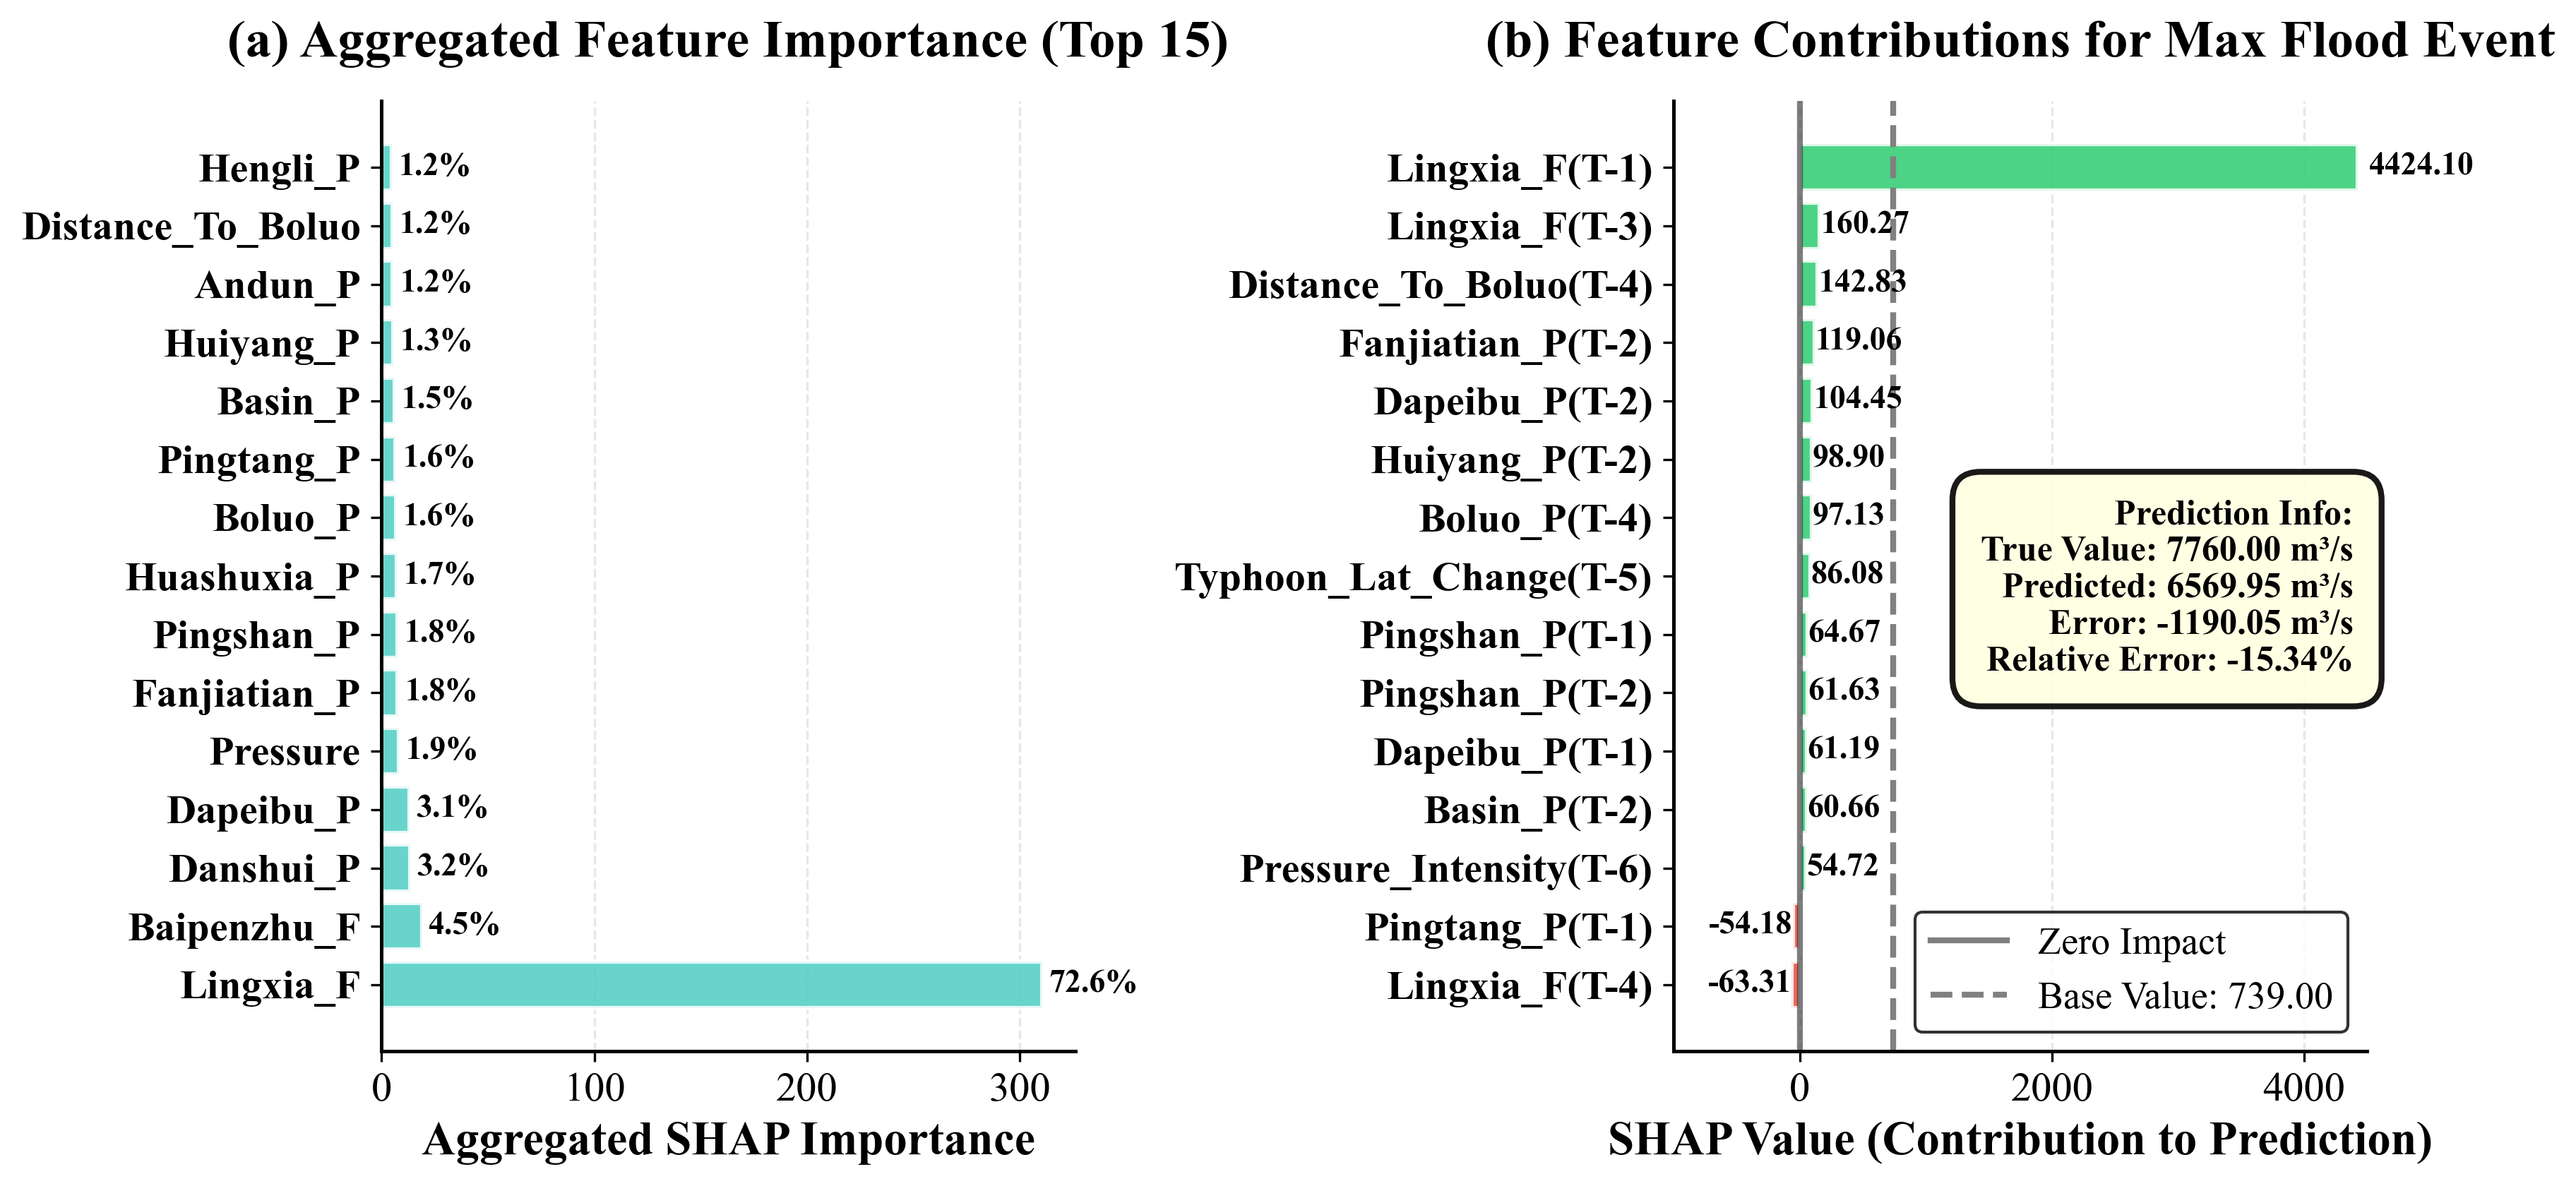


✓ FF-ANN SHAP分析完成！
✓ 图表已保存为: results\Figure7_FF_ANN_SHAP_analysis.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import re
import shap
from sklearn.model_selection import train_test_split

# 设置全局字体和绘图参数
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0

# FF-ANN模型颜色
FF_ANN_COLOR = "#4ecdc4"

# 特征映射：中文 -> 英文
FEATURE_MAPPING = {
    # 流量站点
    '岭下站流量': 'Lingxia_F',
    '白盆珠出库流量': 'Baipenzhu_F',
    
    # 雨量站点
    '大陂布': 'Dapeibu_P',
    '安墩': 'Andun_P',
    '平山': 'Pingshan_P',
    '平潭': 'Pingtang_P',
    '惠阳': 'Huiyang_P',
    '横沥': 'Hengli_P',
    '洋潭': 'Yangtan_P',
    '淡水': 'Danshui_P',
    '清林径': 'Qinglinjing_P',
    '花树下': 'Huashuxia_P',
    '范家田': 'Fanjiatian_P',
    '上坪': 'Shangping_P',
    '三洲田': 'Sanzhoutian_P',
    
    # 博罗站
    '博罗': 'Boluo_P',
    '博罗_T': 'Basin_T',
    '博罗_P': 'Basin_P',
    '博罗_E': 'Basin_E',
    
    # 台风特征
    '台风活跃': 'Typhoon_Active',
    '台风强度编码': 'Typhoon_Intensity',
    '台风距离影响': 'Typhoon_Distance_Impact',
    '台风综合影响': 'Typhoon_Comprehensive',
    '风力等级': 'Wind_Level',
    '气压强度': 'Pressure_Intensity',
    '台风持续天数': 'Typhoon_Duration',
    '台风累积3天': 'Typhoon_Cumsum_3d',
    '台风累积7天': 'Typhoon_Cumsum_7d',
    '台风强度累积3天': 'Typhoon_Intensity_3d',
    '台风强度累积7天': 'Typhoon_Intensity_7d',
    '台风经度变化': 'Typhoon_Lon_Change',
    '台风纬度变化': 'Typhoon_Lat_Change',
    '台风移动速度': 'Typhoon_Speed',
    '台风相对经度': 'Typhoon_Relative_Lon',
    '台风相对纬度': 'Typhoon_Relative_Lat',
    '月份': 'Month',
    '是否台风季': 'Is_Typhoon_Season',
    '台风季节强度': 'Typhoon_Seasonal_Intensity',
    
    # 原始台风特征
    '台风起始距今天数': 'Typhoon_Days_Since',
    '台风经度': 'Typhoon_Lon',
    '台风纬度': 'Typhoon_Lat',
    '台风等级': 'Typhoon_Grade',
    '风速': 'Wind_Speed',
    '气压': 'Pressure',
    '距离博罗站': 'Distance_To_Boluo'
}

# ------------------------------
# 数据和模型加载函数
# ------------------------------
def load_ff_ann_data_and_model(
    train_path='processed_data/train_enhanced.csv',
    test_path='predictions/with_typhoon_enhanced_ANN_predictions.csv',
    model_path='models/with_typhoon_enhanced/ANN_best_model.pkl'
):
    """
    加载FF-ANN模型和增强后的数据
    注意：这里加载的是with_typhoon_enhanced场景下训练的ANN模型
    """
    
    print("="*80)
    print("加载FF-ANN (增强台风特征ANN) 模型和数据")
    print("="*80)
    
    # 标志：是否从predictions文件加载
    from_predictions = False
    
    # 检查文件是否存在
    if not os.path.exists(test_path) or 'predictions' in test_path:
        from_predictions = True
        pred_file = 'predictions/with_typhoon_enhanced_ANN_predictions.csv'
        
        if os.path.exists(pred_file):
            print(f"\n从预测文件加载测试数据: {pred_file}")
            test_data = pd.read_csv(pred_file)
            print(f"  ✓ 测试集样本数: {len(test_data)}")
            
            # 检查列名并标准化
            if 'observed' in test_data.columns:
                test_data['博罗站流量'] = test_data['observed']
                print(f"  ✓ 列名标准化: observed -> 博罗站流量")
        else:
            raise FileNotFoundError(f"预测文件不存在: {pred_file}")
    else:
        print(f"\n加载测试数据: {test_path}")
        test_data = pd.read_csv(test_path)
        print(f"  测试集样本数: {len(test_data)}")
    
    # 从测试集中找出最大径流量样本
    test_flow = test_data['博罗站流量']
    max_test_flow_idx = test_flow.idxmax()
    max_test_flow_value = test_flow.loc[max_test_flow_idx]
    
    # 获取对应日期
    if 'date' in test_data.columns:
        max_date = test_data.loc[max_test_flow_idx, 'date']
        print(f"\n测试集最大径流量样本:")
        print(f"  日期: {max_date}")
        print(f"  索引: {max_test_flow_idx}")
        print(f"  流量值: {max_test_flow_value:.2f} m³/s")
    else:
        print(f"\n测试集最大径流量样本:")
        print(f"  索引: {max_test_flow_idx}")
        print(f"  流量值: {max_test_flow_value:.2f} m³/s")
    
    # 如果是从predictions加载，需要重建特征数据
    if from_predictions:
        print("\n警告: 从predictions文件加载，缺少特征数据")
        print("  尝试从原始数据重建特征...")
        
        # 尝试读取原始的测试集划分数据
        original_test_files = [
            '../数据/test_data_enhanced.csv',
            'test_data_enhanced.csv',
            '../数据/test_enhanced.csv'
        ]
        
        X_test = None
        for test_file in original_test_files:
            if os.path.exists(test_file):
                print(f"  找到原始测试数据: {test_file}")
                test_full = pd.read_csv(test_file)
                X_test = test_full.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
                y_test = test_full['博罗站流量']
                print(f"  ✓ 加载完整测试数据，特征数: {X_test.shape[1]}")
                break
        
        if X_test is None:
            raise FileNotFoundError(
                "无法找到包含特征的测试数据。\n"
                "请提供以下文件之一:\n"
                "  - processed_data/test_enhanced.csv\n"
                "  - ../数据/test_data_enhanced.csv\n"
                "  - test_data_enhanced.csv"
            )
    else:
        # 正常分离特征和目标
        X_test = test_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
        y_test = test_data['博罗站流量']
    
    print(f"\n特征数量: {X_test.shape[1]}")
    print(f"特征列表（前10个）: {X_test.columns.tolist()[:10]}...")
    
    # 提取测试集最大样本的特征和真实值
    max_test_sample_features = X_test.iloc[max_test_flow_idx]
    max_test_sample_true_value = y_test.iloc[max_test_flow_idx]
    
    # 加载训练数据用于SHAP背景采样
    X_train = None
    y_train = None
    
    if os.path.exists(train_path):
        print(f"\n加载训练数据: {train_path}")
        train_data = pd.read_csv(train_path)
        X_train = train_data.drop(['博罗站流量', 'date'], axis=1, errors='ignore')
        y_train = train_data['博罗站流量']
        print(f"  ✓ 训练集样本数: {len(train_data)}")
    else:
        print(f"\n警告: 训练数据不存在: {train_path}")
        print("  将使用测试数据的一部分作为SHAP背景")
    
    # 划分样本集用于SHAP分析
    if X_train is not None and len(X_train) > 0:
        sample_size = min(100, int(len(X_train) * 0.1))
        X_sample, _, _, _ = train_test_split(
            X_train, y_train,
            test_size=(len(X_train) - sample_size) / len(X_train),
            random_state=42
        )
        print(f"\nSHAP分析背景样本数（从训练集）: {len(X_sample)}")
    else:
        # 使用测试数据的一部分
        sample_size = min(100, int(len(X_test) * 0.3))
        X_sample = X_test.sample(n=sample_size, random_state=42)
        print(f"\nSHAP分析背景样本数（从测试集）: {len(X_sample)}")
    
    # 加载FF-ANN模型
    print(f"\n加载FF-ANN模型: {model_path}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"模型文件不存在: {model_path}")
    
    ff_ann_model = joblib.load(model_path)
    print(f"  ✓ 模型加载成功")
    
    # 计算FF-ANN对最大样本的预测值
    max_test_sample_pred_value = ff_ann_model.predict(
        max_test_sample_features.values.reshape(1, -1)
    )[0]
    
    error = max_test_sample_pred_value - max_test_sample_true_value
    relative_error = (error / max_test_sample_true_value) * 100
    
    print(f"\n最大样本预测结果:")
    print(f"  真实值: {max_test_sample_true_value:.2f} m³/s")
    print(f"  预测值: {max_test_sample_pred_value:.2f} m³/s")
    print(f"  误差: {error:+.2f} m³/s")
    print(f"  相对误差: {relative_error:+.2f}%")
    
    return {
        'X_train': X_train if X_train is not None else X_sample,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_sample': X_sample,
        'feature_names': X_test.columns.tolist(),
        'model': ff_ann_model,
        'max_test_flow_idx': max_test_flow_idx,
        'max_test_flow_value': max_test_flow_value,
        'max_test_sample_pred_value': max_test_sample_pred_value,
        'max_test_sample_features': max_test_sample_features,
        'max_test_sample_true_value': max_test_sample_true_value
    }

# ------------------------------
# 特征名称处理函数
# ------------------------------
def extract_base_feature(feature_name):
    """从带lag的特征名中提取基础特征名，处理(T-N)格式"""
    # 移除 (T-N) 格式
    return re.sub(r'\(T-\d+\)$', '', feature_name)

def translate_feature_name(feature):
    """将单个中文特征名翻译为英文"""
    # 先提取基础特征名（去除lag部分）
    base_feature = extract_base_feature(feature)
    
    # 查找映射
    if base_feature in FEATURE_MAPPING:
        english_base = FEATURE_MAPPING[base_feature]
        # 提取lag信息
        lag_match = re.search(r'\(T-(\d+)\)', feature)
        if lag_match:
            return f"{english_base}(T-{8-lag_match.group(1)})"
        else:
            return english_base
    
    # 如果没有找到映射，保持原样
    return feature

def translate_feature_names(features):
    """将中文特征名列表翻译为英文"""
    return [translate_feature_name(f) for f in features]

# ------------------------------
# SHAP分析函数
# ------------------------------
def calculate_shap_values(data, use_gpu=False, save_path=None):
    """计算FF-ANN模型的SHAP值"""
    
    print("\n" + "="*80)
    print("计算SHAP值")
    print("="*80)
    
    model = data['model']
    X_sample = data['X_sample'].copy()
    X_test = data['X_test'].copy()
    feature_names = data['feature_names']
    
    # 转换特征名为英文
    english_features = translate_feature_names(feature_names)
    X_sample.columns = english_features
    X_test.columns = english_features
    
    print("\n初始化SHAP解释器...")
    print(f"  背景样本数: {min(100, len(X_sample))}")
    
    explainer = shap.KernelExplainer(
        model.predict,
        X_sample.sample(min(100, len(X_sample)), random_state=42)
    )
    
    print("\n计算SHAP值（这可能需要几分钟时间）...")
    print(f"  测试样本数: {len(X_test)}")
    
    shap_values = explainer.shap_values(
        X_test,
        nsamples=200,
        l1_reg="auto"
    )
    
    print(f"  ✓ SHAP值计算完成")
    print(f"  SHAP矩阵形状: {shap_values.shape}")
    
    results = {
        'shap_values': shap_values,
        'X_test': X_test,
        'feature_names': english_features,
        'expected_value': explainer.expected_value
    }
    
    # 保存计算结果
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        joblib.dump(results, save_path)
        print(f"\n✓ SHAP结果已保存至: {save_path}")
    
    return results

def load_shap_results(load_path):
    """加载已保存的SHAP计算结果"""
    if not os.path.exists(load_path):
        return None
    
    if os.path.getsize(load_path) < 1024:
        print(f"检测到可能损坏的SHAP结果文件，将重新计算")
        try:
            os.remove(load_path)
        except:
            pass
        return None
    
    try:
        print(f"加载已保存的SHAP结果: {load_path}")
        results = joblib.load(load_path)
        print(f"  ✓ SHAP结果加载成功")
        return results
    except Exception as e:
        print(f"加载SHAP结果失败: {str(e)}")
        print("将重新计算SHAP值...")
        try:
            os.remove(load_path)
        except:
            pass
        return None

def analyze_shap_importance(shap_results):
    """分析SHAP特征重要性"""
    
    print("\n" + "="*80)
    print("分析SHAP特征重要性")
    print("="*80)
    
    # 计算特征重要性（SHAP值的绝对值平均值）
    feature_importance = np.mean(np.abs(shap_results['shap_values']), axis=0)
    
    # 创建重要性DataFrame
    importance_df = pd.DataFrame({
        'feature': shap_results['feature_names'],
        'shap_importance': feature_importance
    }).sort_values('shap_importance', ascending=False)
    
    print(f"\n原始特征数: {len(importance_df)}")
    print("\nTop 10 重要特征:")
    for i, row in importance_df.head(10).iterrows():
        print(f"  {row['feature']}: {row['shap_importance']:.6f}")
    
    # 聚合滞后特征的重要性（去除(T-N)部分）
    importance_df['base_feature'] = importance_df['feature'].apply(
        lambda x: re.sub(r'\(T-\d+\)$', '', x)
    )
    aggregated_importance = importance_df.groupby('base_feature')['shap_importance'].sum().reset_index()
    aggregated_importance = aggregated_importance.sort_values('shap_importance', ascending=False)
    
    # 归一化
    aggregated_importance['shap_importance_normalized'] = (
        aggregated_importance['shap_importance'] / aggregated_importance['shap_importance'].sum()
    )
    
    print(f"\n聚合后基础特征数: {len(aggregated_importance)}")
    print("\nTop 10 聚合特征:")
    for i, row in aggregated_importance.head(10).iterrows():
        print(f"  {row['base_feature']}: {row['shap_importance']:.6f} ({row['shap_importance_normalized']*100:.2f}%)")
    
    return {
        'raw_importance': importance_df,
        'aggregated_importance': aggregated_importance
    }

# ------------------------------
# 主绘图函数 - 1x2布局
# ------------------------------
def plot_ff_ann_shap_analysis(data, shap_results, shap_importance,
                               output_file='results/Figure7_FF_ANN_SHAP_analysis.png',
                               top_n=15, dpi=300):
    """
    生成FF-ANN的SHAP分析图（1行2列）:
    (a) 聚合特征重要性
    (b) 最大样本的特征贡献
    """
    
    print("\n" + "="*80)
    print("绘制FF-ANN SHAP分析图")
    print("="*80)
    
    # 提取所需数据
    max_test_idx = data['max_test_flow_idx']
    max_test_true_value = data['max_test_sample_true_value']
    max_test_pred_value = data['max_test_sample_pred_value']
    
    shap_values = shap_results['shap_values']
    feature_names = shap_results['feature_names']
    expected_value = shap_results['expected_value']
    
    # 创建1x2子图
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=dpi)
    
    # ------------------------------
    # (a) 左图：聚合特征重要性
    # ------------------------------
    ax1 = axes[0]
    
    aggregated = shap_importance['aggregated_importance'].head(top_n)
    
    y_pos = np.arange(len(aggregated))
    bars = ax1.barh(y_pos, aggregated['shap_importance'][::-1],
                    color=FF_ANN_COLOR, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # 添加数值标签
    for bar in bars:
        width = bar.get_width()
        percentage = (width / aggregated['shap_importance'].sum()) * 100
        ax1.text(width + aggregated['shap_importance'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(aggregated['base_feature'][::-1], fontsize=14, fontweight='bold')
    ax1.set_xlabel('Aggregated SHAP Importance', fontsize=16, fontweight='bold')
    ax1.set_title('(a) Aggregated Feature Importance (Top 15)',
                 fontsize=18, fontweight='bold', pad=15)
    ax1.invert_yaxis()
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(axis='x', linestyle='--', alpha=0.3)
    ax1.set_axisbelow(True)
    
    # ------------------------------
    # (b) 右图：最大样本的特征贡献
    # ------------------------------
    ax2 = axes[1]
    
    # 获取所有特征的SHAP值并排序（取绝对值最大的top_n个）
    sample_shap = shap_values[max_test_idx, :]
    abs_shap = np.abs(sample_shap)
    top_indices = np.argsort(abs_shap)[-top_n:][::-1]
    
    top_shap_values = sample_shap[top_indices]
    top_feature_names = [feature_names[i] for i in top_indices]
    
    # 按SHAP值排序（从负到正）
    sorted_idx = np.argsort(top_shap_values)
    sorted_shap = top_shap_values[sorted_idx]
    sorted_features = [top_feature_names[i] for i in sorted_idx]
    
    # 绘制水平条形图（负值红色，正值绿色）
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sorted_shap]
    bars = ax2.barh(range(len(sorted_shap)), sorted_shap,
                    color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    # 添加数值标签
    for i, (bar, value) in enumerate(zip(bars, sorted_shap)):
        width = bar.get_width()
        x_pos = width + (abs(width) * 0.02 if width > 0 else -abs(width) * 0.02)
        ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{value:.2f}',
                ha='left' if width > 0 else 'right',
                va='center', fontsize=11, fontweight='bold')
    
    # 添加基准线
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.5, label='Zero Impact')
    ax2.axvline(x=expected_value, color='gray', linestyle='--', linewidth=2,
               label=f'Base Value: {expected_value:.2f}')
    
    # 在图的右侧添加预测信息文本框
    info_text = f'Prediction Info:\n' \
                f'True Value: {max_test_true_value:.2f} m³/s\n' \
                f'Predicted: {max_test_pred_value:.2f} m³/s\n' \
                f'Error: {max_test_pred_value - max_test_true_value:+.2f} m³/s\n' \
                f'Relative Error: {(max_test_pred_value - max_test_true_value) / max_test_true_value * 100:+.2f}%'
    
    ax2.text(0.98, 0.58, info_text,
            transform=ax2.transAxes,
            fontsize=12, fontweight='bold',
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8',
                     facecolor='lightyellow',
                     alpha=0.9,
                     edgecolor='black',
                     linewidth=2))

    ax2.set_xlim(-1000, 4500)
    ax2.set_yticks(range(len(sorted_shap)))
    sorted_features = [s[:-2]+str(8-int(s[-2]))+')' for s in sorted_features]
    ax2.set_yticklabels(sorted_features, fontsize=14, fontweight='bold')
    ax2.set_xlabel('SHAP Value (Contribution to Prediction)', fontsize=16, fontweight='bold')
    ax2.set_title(f'(b) Feature Contributions for Max Flood Event',
                 fontsize=18, fontweight='bold', pad=15)
    ax2.legend(fontsize=13, loc='lower right', frameon=True, edgecolor='black')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(axis='x', linestyle='--', alpha=0.3)
    ax2.set_axisbelow(True)
    
    # 调整布局
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"\n✓ 图表已保存至: {output_file}")
    
    plt.show()
    
    return output_file

# ------------------------------
# 主函数
# ------------------------------
def main():
    """主函数：执行FF-ANN的SHAP分析"""
    
    # 配置参数 - 使用你的训练流程中的路径
    train_path = 'processed_data/train_enhanced.csv'  # 如果有的话
    test_path = 'predictions/with_typhoon_enhanced_ANN_predictions.csv'  # 从预测文件获取测试数据
    model_path = 'models/with_typhoon_enhanced/ANN_best_model.pkl'  # FF-ANN模型路径
    output_dir = 'results'
    shap_save_path = os.path.join(output_dir, 'ff_ann_shap_results.pkl')
    output_figure = os.path.join(output_dir, 'Figure7_FF_ANN_SHAP_analysis.png')
    use_gpu = False
    top_n_features = 15
    
    os.makedirs(output_dir, exist_ok=True)
    
    try:
        # 步骤1: 加载数据和模型
        print("\n步骤 1/4: 加载FF-ANN模型和数据")
        data = load_ff_ann_data_and_model(
            train_path=train_path,
            test_path=test_path,
            model_path=model_path
        )
        
        # 步骤2: 计算或加载SHAP值
        print("\n步骤 2/4: 计算或加载SHAP值")
        shap_results = load_shap_results(shap_save_path)
        
        if shap_results is None:
            shap_results = calculate_shap_values(
                data,
                use_gpu=use_gpu,
                save_path=shap_save_path
            )
        else:
            print("  ✓ 已加载保存的SHAP结果，跳过计算步骤")
        
        # 步骤3: 分析SHAP重要性
        print("\n步骤 3/4: 分析SHAP特征重要性")
        shap_importance = analyze_shap_importance(shap_results)
        
        # 步骤4: 生成图表
        print("\n步骤 4/4: 生成Figure 7")
        plot_ff_ann_shap_analysis(
            data,
            shap_results,
            shap_importance,
            output_file=output_figure,
            top_n=top_n_features,
            dpi=300
        )
        
        print("\n" + "="*80)
        print("✓ FF-ANN SHAP分析完成！")
        print(f"✓ 图表已保存为: {output_figure}")
        print("="*80)
        
        return data, shap_results, shap_importance
        
    except Exception as e:
        print(f"\n✗ 执行过程中出错: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

if __name__ == "__main__":
    data, shap_results, shap_importance = main()